<a href="https://colab.research.google.com/github/vstimpson/scientific-computing-projects/blob/main/Another_copy_of_Session7_IA_SciComp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<hr style="border:1px solid black"> </hr>

## Section 2. Submitting Your Work for Course Credit

  You will write a small program obtaining and plotting the
equilibrium order parameter in a metallic alloy versus temperature.
  This program will loop over values of temperature,
minimising a free-energy expression for each one of them.
  This free energy will be defined as a function.

### The Bragg-Williams model

  In many materials, such as metal alloys, there is a transition between
two phases in which the atoms are ordered or disordered over
sites within the crystal.
  The potential energy prefers the ordered state, but the entropy prefers
the disordered state.
  The contributions to the overall energy from the potential energy and
the entropy can be written in terms of what is called a free energy,
given the symbol $F$, and the state of order can be characterised by a
quantity called the order parameter, $Q$, whose value varies between
$Q = 1$ for fully ordered and $Q = 0$ for completely disordered.
  One early attempt to develop a theory for this type of phase transition,
now known as the Bragg-Williams model, led to the following expression
for the free energy:

\begin{equation*}
F = -T_c Q^2 +T [(1+Q)\ln(1+Q)+(1-Q)\ln(1-Q)]
\end{equation*}

where $T$ is the temperature, and the parameter $T_c$ turns out to be
the temperature of the phase transition.
 The equilibrium value of $Q$ at any temperature is that for which $F$
is a minimum.

### Exercise

- Write a function `bw` of `q`, returning the free energy $F$. Not to worry
  about `Tc` and `T`, they wiil be defined externally.  
- Plot $F$ versus $Q$ using the `bw` function, for
  $Q \in (-1.0, 1.0)$ (excluding the limits), with $T_c =1.0$,
  and for three values of the temperature $T=0.8$,
  $1.0$, and $1.4$ (as three superimposed curves).
- Write a program that loops over 200 values of $T$ between
  0.5 and 1.2, and for each temperature finds the equilibrium
  $Q_e(T)$, i.e. the value of $Q$ that minimises the free energy $F$
  at a given $T$ (always use $T_c=1.0$), using `minimize` with the
  `bw` function defined above.
  (Careful with the initial value of $Q$ in the minimisation, since
  the process can take it to values that the $\log$ may dislike.
  0.9 seems to work).
- Structure the program in such a way that it contains
  initialisations of the main variables at the beginning with
  comments describing them (number of values of $T$, initial
  and final values of $T$, same for $Q$ for the initial figure etc.)
- Plot the obtained values of $Q_e$ versus $T$.
  See the transition from finite to zero $Q_e$ at $T=T_c$.
  Plot the curve with a thicker line than the one used for
  the axes, so that it can be distinguished if they overlap.
- Have both the program and the function well documented with
  comments, appropriate indentation and empty-line separations.
  
**Following the instructions on Moodle, submit the Jupyter notebook with the generated code and figures.**

In [ ]:
import numpy as np

def bw(q):

  term1 = -Tc * q**2
  term2 = T * ((1 + q) * np.log(1 + q) + (1 - q) * np.log(1 - q))
  F = term1 + term2
  return F

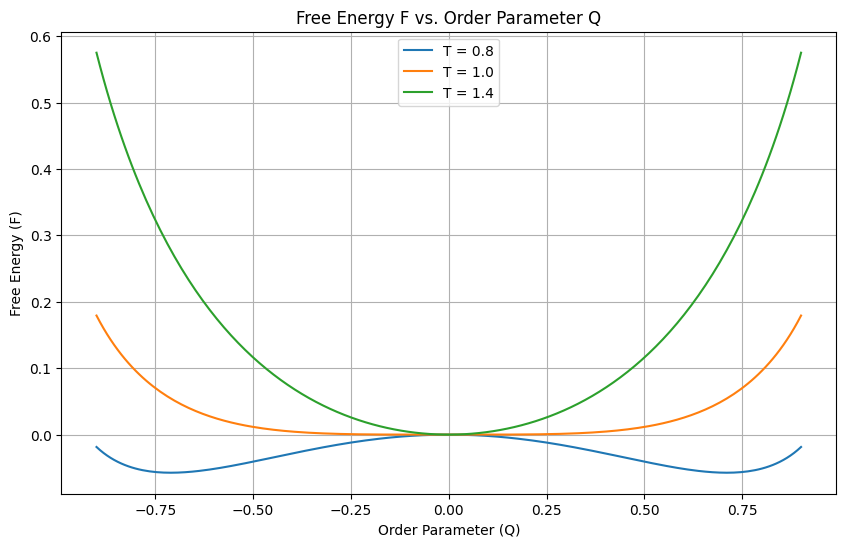

In [ ]:
# Define Tc and T values for plotting
Tc = 1.0
T_values = [0.8, 1.0, 1.4]

# Generate Q values
Q_min = -0.9
Q_max = 0.9
Q_steps = 200
Q = np.linspace(Q_min, Q_max, Q_steps)

# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Plot F versus Q for different T values
plt.figure(figsize=(10, 6))
for T in T_values:
    F_values = bw(Q)
    plt.plot(Q, F_values, label=f'T = {T}')

plt.xlabel('Order Parameter (Q)')
plt.ylabel('Free Energy (F)')
plt.title('Free Energy F vs. Order Parameter Q')
plt.grid(True)
plt.legend()
plt.show()

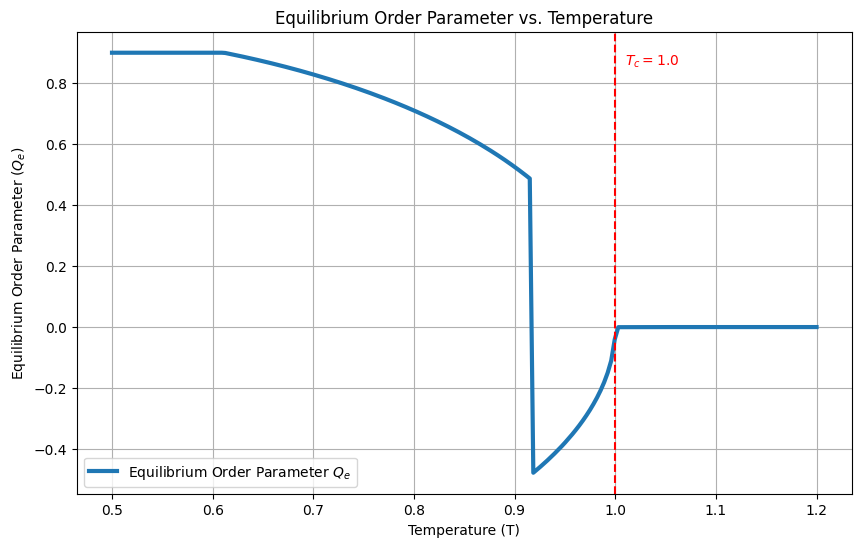

In [ ]:
from scipy.optimize import minimize

# Initializations
Tc = 1.0
T_start = 0.5
T_end = 1.2
num_T_values = 200

# Generate temperature values
T_loop_values = np.linspace(T_start, T_end, num_T_values)

# List to store equilibrium Q values
Q_eq_values = []

# Loop over temperature values to find equilibrium Q
for current_T in T_loop_values:

    T = current_T

    objective_function = lambda q_val: bw(q_val)

    q_initial = 0.9

    # Perform minimization
    result = minimize(objective_function, q_initial, bounds=[(-0.9, 0.9)])

    # Store the equilibrium Q value
    Q_eq_values.append(result.x[0])

# Plot the obtained Q_e versus T
plt.figure(figsize=(10, 6))
plt.plot(T_loop_values, Q_eq_values, linewidth=3, label='Equilibrium Order Parameter $Q_e$')
plt.xlabel('Temperature (T)')
plt.ylabel('Equilibrium Order Parameter ($Q_e$)')
plt.title('Equilibrium Order Parameter vs. Temperature')
plt.grid(True)
plt.legend()
plt.axvline(x=Tc, color='r', linestyle='--', label=f'$T_c = {Tc}$', linewidth=1.5)

plt.text(Tc + 0.01, plt.ylim()[1] * 0.9, f'$T_c = {Tc}$', color='r', ha='left', va='center')
plt.show()